### **Inversion Detection Algorithm**

- **Definition:** an inversion is any layer where temperature increases with height (dT/dz > 0), split into **surface-based** (starts at the lowest reported level) and **elevated** (starts higher up) — following the standard approach used in radiosonde inversion climatologies (Kahl 1990; Zhang et al. 2011).
- **Noise tolerance:** the algorithm tracks a *running peak* temperature as it scans upward. A dip below that peak is tolerated for up to `EMBED_TOLERANCE_M` (10 m) past the peak's height — if temperature recovers to a new high within that window, the layer keeps extending; if not, the layer closes at the last confirmed peak. This tolerance resets at every new peak, so several small dips can occur throughout one layer without breaking it.
- **Strength & depth are whole-layer quantities**, not single-step gradients: `depth = top height − base height`, `deltaT = T(top) − T(base)`, `mean_gradient = deltaT / depth` — matching how the field defines SBI/EI strength and depth.
- **Known assumptions to keep in mind:** "height" is measured above the *first valid reading* in each sounding (a proxy for ground level, not a guaranteed exact match), the search is capped at `MAX_HEIGHT_M` (so a real inversion deeper than that gets reported with a clipped ΔT), and `EMBED_TOLERANCE_M` was scaled to this station's own ~5-6 m vertical resolution rather than copied from literature values calibrated on coarser networks — validate it visually against the shaded overlay, not just trust it.
- **What's reported:** for each sounding, the strongest surface-based layer and the strongest elevated layer (if either exists) are kept; weaker/thinner candidates (depth < 15 m) are discarded as noise-scale, not real features.

                      file              termin  surface_deltaT  surface_depth  \
0  20251004_06610_data.txt 2025-10-04 00:00:00             0.3           36.0   
1  20251004_06610_data.txt 2025-10-04 12:00:00             NaN            NaN   
2  20251005_06610_data.txt 2025-10-05 00:00:00             0.9           58.0   
3  20251005_06610_data.txt 2025-10-05 12:00:00             NaN            NaN   
4  20251006_06610_data.txt 2025-10-06 00:00:00             NaN            NaN   

   surface_gradient  elevated_deltaT  elevated_height  elevated_gradient  
0          0.008333             1.80            409.0           0.020000  
1               NaN             0.23            234.0           0.010000  
2          0.015517             0.53             64.0           0.016061  
3               NaN             0.09             19.0           0.007500  
4               NaN             0.31             88.0           0.009118  

Strongest surface-based inversions:


,file,termin,surface_deltaT,surface_depth,surface_gradient,elevated_deltaT,elevated_height,elevated_gradient
0,20251004_06610_data.txt,2025-10-04 00:00:00,0.30,36.0,0.008333,1.80,409.0,0.020000
2,20251005_06610_data.txt,2025-10-05 00:00:00,0.90,58.0,0.015517,0.53,64.0,0.016061
5,20251006_06610_data.txt,2025-10-06 12:00:00,0.36,10.0,0.036000,0.03,117.0,0.001579
8,20251008_06610_data.txt,2025-10-08 00:00:00,2.46,104.0,0.023654,0.39,332.0,0.006393
11,20251009_06610_data.txt,2025-10-09 12:00:00,0.48,10.0,0.048000,0.01,124.0,0.000769
12,20251010_06610_data.txt,2025-10-10 00:00:00,0.05,15.0,0.003333,0.18,72.0,0.005294
14,20251011_06610_data.txt,2025-10-11 00:00:00,0.21,27.0,0.007778,0.02,45.0,0.001176



Strongest elevated inversions:


,file,termin,surface_deltaT,surface_depth,surface_gradient,elevated_deltaT,elevated_height,elevated_gradient
0,20251004_06610_data.txt,2025-10-04 00:00:00,0.30,36.0,0.008333,1.80,409.0,0.020000
1,20251004_06610_data.txt,2025-10-04 12:00:00,NaN,NaN,NaN,0.23,234.0,0.010000
2,20251005_06610_data.txt,2025-10-05 00:00:00,0.90,58.0,0.015517,0.53,64.0,0.016061
3,20251005_06610_data.txt,2025-10-05 12:00:00,NaN,NaN,NaN,0.09,19.0,0.007500
4,20251006_06610_data.txt,2025-10-06 00:00:00,NaN,NaN,NaN,0.31,88.0,0.009118
5,20251006_06610_data.txt,2025-10-06 12:00:00,0.36,10.0,0.036000,0.03,117.0,0.001579
6,20251007_06610_data.txt,2025-10-07 00:00:00,NaN,NaN,NaN,1.24,23.0,0.016533
7,20251007_06610_data.txt,2025-10-07 12:00:00,NaN,NaN,NaN,0.19,29.0,0.008261
8,20251008_06610_data.txt,2025-10-08 00:00:00,2.46,104.0,0.023654,0.39,332.0,0.006393
9,20251008_06610_data.txt,2025-10-08 12:00:00,NaN,NaN,NaN,0.73,427.0,0.020857


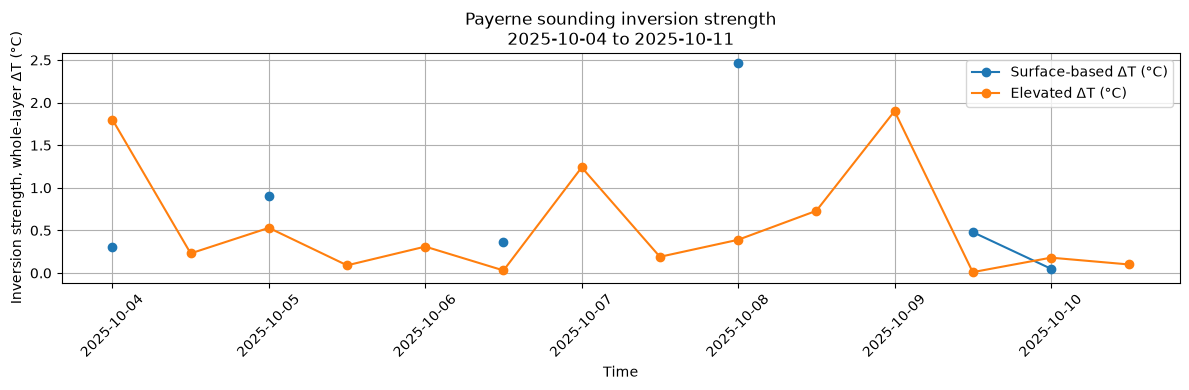

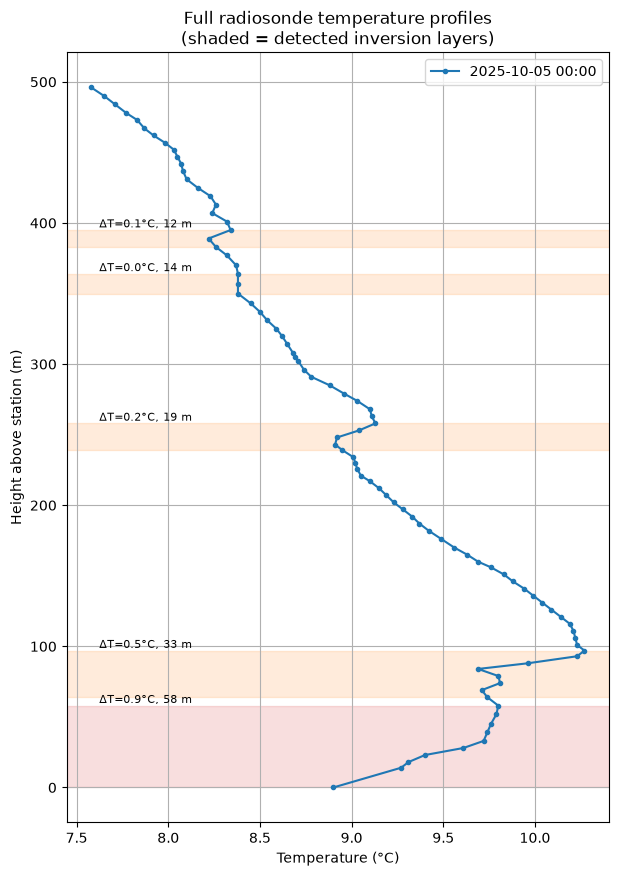

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# CONFIG
# ==========================================================
SOUNDINGS_DIR = Path("/scratch/mch/jdelbeke/soundings/output")
STATION_ID = "06610"
MAX_HEIGHT_M = 500
MISSING_VALUE = 10000000
TERMIN_FMT = "%Y%m%d%H%M%S"

EMBED_TOLERANCE_M = 10
MIN_LAYER_DEPTH_M = EMBED_TOLERANCE_M  

CUTOFF = pd.Timestamp("2025-08-01")
PLOT_START, PLOT_END = pd.Timestamp("2025-10-04"), pd.Timestamp("2025-10-11")
PROFILE_CASES = [("20251005_06610_data.txt", "20251005000000")]


# ==========================================================
# HELPERS
# ==========================================================
def parse_termin(x):
    """Parse a termin string/int (e.g. '20260105000000') into a Timestamp, explicitly."""
    return pd.to_datetime(str(x), format=TERMIN_FMT)


def read_sounding(file):
    """Parse one day's raw sounding file (all termins, all levels)."""
    with open(file) as f:
        header = f.readlines()[1].split()
    return pd.read_csv(
        file, sep=r"\s*\|\s*", engine="python",
        skiprows=3, header=None, names=header,
    )


def load_profiles(file):
    """
    Return {termin: profile_df} for every launch in one day's file.
    Height ('742') is expressed above the lowest reported level for that
    launch - used here as a proxy for height above station; temperature
    is '745'. Missing-value sentinel is masked before any calculation.
    """
    df = read_sounding(file)
    df["termin"] = df["termin"].astype(str).apply(parse_termin)

    profiles = {}
    for termin, sounding in df.groupby("termin"):
        profile = (
            sounding[["742", "745"]]
            .replace(MISSING_VALUE, np.nan)
            .dropna()
            .rename(columns={"742": "height", "745": "temperature"})
            .sort_values("height")
        )
        if profile.empty:
            continue
        profile["height"] -= profile["height"].iloc[0]
        profile = profile.groupby("height", as_index=False)["temperature"].mean().sort_values("height")
        profiles[termin] = profile

    return profiles


def find_inversion_layers(profile, max_height=MAX_HEIGHT_M,
                           embed_tolerance_m=EMBED_TOLERANCE_M,
                           min_depth_m=MIN_LAYER_DEPTH_M):

    prof = profile[profile["height"] <= max_height]
    z, T = prof["height"].values, prof["temperature"].values
    n = len(z)
    if n < 3:
        return []

    layers = []
    i = 0
    while i < n - 1:
        base = top = i
        j = i + 1
        while j < n:
            if T[j] >= T[top]:
                top = j
                j += 1
            elif z[j] - z[top] <= embed_tolerance_m:
                j += 1  # shallow dip within tolerance - keep scanning for recovery
            else:
                break   # dip too deep/persistent - layer genuinely ends at 'top'

        depth = z[top] - z[base]
        if top > base and depth >= min_depth_m:
            layers.append({
                "base_height": z[base], "top_height": z[top],
                "depth": depth, "deltaT": T[top] - T[base],
                "mean_gradient": (T[top] - T[base]) / depth,
                "surface_based": z[base] == 0,
            })
            i = top + 1
        else:
            i += 1

    return layers


# ==========================================================
# BUILD RESULTS TABLE (all soundings, surface + elevated)
# ==========================================================
files = sorted(SOUNDINGS_DIR.glob(f"*_{STATION_ID}_data.txt"))

results = []
for file in files:
    for termin, profile in load_profiles(file).items():
        if termin < CUTOFF:
            continue

        layers = find_inversion_layers(profile)
        surface = next((l for l in layers if l["surface_based"]), None)
        elevated = max(
            (l for l in layers if not l["surface_based"]),
            key=lambda l: l["deltaT"], default=None
        )

        results.append({
            "file": file.name,
            "termin": termin,
            "surface_deltaT": surface["deltaT"] if surface else np.nan,
            "surface_depth": surface["depth"] if surface else np.nan,
            "surface_gradient": surface["mean_gradient"] if surface else np.nan,
            "elevated_deltaT": elevated["deltaT"] if elevated else np.nan,
            "elevated_height": elevated["base_height"] if elevated else np.nan,
            "elevated_gradient": elevated["mean_gradient"] if elevated else np.nan,
        })

results = pd.DataFrame(results)
print(results.head())


# ==========================================================
# STRONGEST 25: SURFACE-BASED AND ELEVATED
# ==========================================================
surface_top25 = (results.dropna(subset=["surface_deltaT"])
                  .sort_values("surface_deltaT", ascending=False).head(25))
elevated_top25 = (results.dropna(subset=["elevated_deltaT"])
                   .sort_values("elevated_deltaT", ascending=False).head(25))

print("\nStrongest surface-based inversions:")
with pd.option_context("display.max_rows", None):
    display(surface_top25.sort_values("termin"))

print("\nStrongest elevated inversions:")
with pd.option_context("display.max_rows", None):
    display(elevated_top25.sort_values("termin"))


# ==========================================================
# TIME SERIES: SURFACE VS ELEVATED STRENGTH
# ==========================================================
plot_data = results[(results["termin"] >= PLOT_START) & (results["termin"] < PLOT_END)].sort_values("termin")

plt.figure(figsize=(12, 4))
plt.plot(plot_data["termin"], plot_data["surface_deltaT"], marker="o", label="Surface-based ΔT (°C)")
plt.plot(plot_data["termin"], plot_data["elevated_deltaT"], marker="o", label="Elevated ΔT (°C)")
plt.xlabel("Time")
plt.ylabel("Inversion strength, whole-layer ΔT (°C)")
plt.title(f"Payerne sounding inversion strength\n{PLOT_START:%Y-%m-%d} to {PLOT_END:%Y-%m-%d}")
plt.grid()
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ==========================================================
# FULL PROFILE PLOT WITH DETECTED LAYERS SHADED (validation vs. emagram)
# ==========================================================
plt.figure(figsize=(7, 10))
for file_name, termin_str in PROFILE_CASES:
    profile = load_profiles(SOUNDINGS_DIR / file_name)[parse_termin(termin_str)]
    profile = profile[profile["height"] <= MAX_HEIGHT_M]  # match the detection height cap
    plt.plot(profile["temperature"], profile["height"], marker="o", markersize=3,
              label=f"{parse_termin(termin_str):%Y-%m-%d %H:%M}")

    for layer in find_inversion_layers(profile):
        color = "tab:red" if layer["surface_based"] else "tab:orange"
        plt.axhspan(layer["base_height"], layer["top_height"], color=color, alpha=0.15)
        plt.text(profile["temperature"].min(), layer["top_height"],
                  f"  ΔT={layer['deltaT']:.1f}°C, {layer['depth']:.0f} m", fontsize=8, va="bottom")

plt.xlabel("Temperature (°C)")
plt.ylabel("Height above station (m)")
plt.title("Full radiosonde temperature profiles\n(shaded = detected inversion layers)")
plt.grid()
plt.legend()
plt.show()